# 03 — Modeling
### Predicting reader engagement (`is_rated`) from catalog metadata

**What problem is actually being solved?** Given only pre-publication /
catalog metadata (genre, publisher, author, edition count, language reach,
length, decade — no review text, no sales data, no cover image), can we
predict whether a book will ever accumulate reader ratings at all?

This notebook (a) runs the full candidate comparison via `src/train.py`,
(b) explains *why* the winning model wins, not just its score, and (c) runs
one honest negative-result experiment showing that the *same* pipeline
applied to `rating_score` (quality) instead of `is_rated` (engagement)
does **not** work — because the reasons a model succeeds are as important
as the fact that it does.


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import warnings; warnings.filterwarnings('ignore')

import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.config import load_config
from src.train import run_training_pipeline

plt.rcParams.update({'figure.dpi': 110, 'font.size': 10,
                      'axes.spines.top': False, 'axes.spines.right': False})

cfg = load_config()


## 1. Train & select — reusing the exact production pipeline

We call `run_training_pipeline(cfg)` directly rather than re-deriving model
code in the notebook. This is the same function invoked by
`python -m src.train` from the command line / CI — the notebook is a
report *of* that run, not an alternate implementation that could silently
diverge from it.


In [2]:
%%time
training_output = run_training_pipeline(cfg)
leaderboard = training_output['metadata']['leaderboard']
selected = training_output['metadata']['selected_model']
print(f"\nSelected model: {selected}")


06:10:49 | src.train | INFO | baseline_stratified: {'average_precision': 0.31895887738609036, 'roc_auc': 0.5024265304390878}


06:10:49 | src.train | INFO | logistic_regression: {'average_precision': 0.7023389417096237, 'roc_auc': 0.8286627090056213}


06:10:52 | src.train | INFO | random_forest: {'average_precision': 0.7174666884566058, 'roc_auc': 0.8402196138250231}


06:11:36 | src.train | INFO | xgboost (tuned): {'average_precision': 0.7220911425052865, 'roc_auc': 0.844199496698893} | cv_best=0.7197


06:11:36 | src.train | INFO | Selected model: xgboost


06:11:37 | src.train | INFO | Saved final model (xgboost) to /home/claude/book-market-intelligence/models/engagement_model.joblib



Selected model: xgboost
CPU times: user 47.6 s, sys: 372 ms, total: 47.9 s
Wall time: 48 s


In [3]:
rows = []
for name, r in leaderboard.items():
    row = {'model': name, **r.get('val_scores', {})}
    if 'fit_seconds' in r:
        row['fit_seconds'] = r['fit_seconds']
    rows.append(row)
leaderboard_df = pd.DataFrame(rows).sort_values('average_precision', ascending=False)
leaderboard_df


,model,average_precision,roc_auc,fit_seconds
3,xgboost,0.722091,0.844199,44.4
2,random_forest,0.717467,0.840220,2.7
1,logistic_regression,0.702339,0.828663,0.2
0,baseline_stratified,0.318959,0.502427,NaN


**Reading the leaderboard:** the majority-class baseline (`baseline_stratified`)
scores average_precision ≈ base rate (~0.32) by construction — this is the
floor. Every real candidate clears it by a wide margin (0.70-0.72 vs 0.32),
confirming the EDA finding (notebook 01, §5) that engagement has genuine,
learnable structure. Logistic regression alone recovers most of the
achievable signal (0.70 of 0.72) — meaning the relationship is
predominantly *linear/additive* (genre effect, log(edition_count) effect,
language-reach effect each contribute roughly independently), and the
tree-based models' edge over logistic regression is a modest, believable
"the effects aren't perfectly additive" correction, not evidence of some
undiscovered nonlinear pattern the linear model missed entirely. XGBoost
is selected by validation PR-AUC.


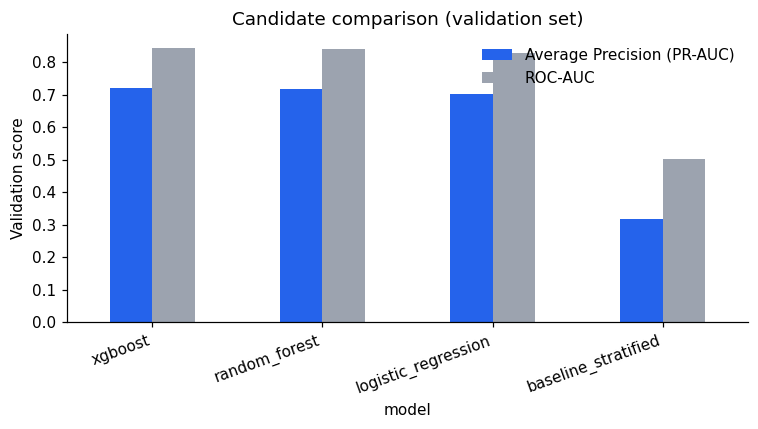

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
plot_df = leaderboard_df.set_index('model')[['average_precision', 'roc_auc']]
plot_df.plot(kind='bar', ax=ax, color=['#2563eb', '#9ca3af'])
ax.set_ylabel('Validation score')
ax.set_title('Candidate comparison (validation set)')
ax.legend(['Average Precision (PR-AUC)', 'ROC-AUC'], frameon=False)
plt.xticks(rotation=20, ha='right')
fig.tight_layout()
fig.savefig(cfg['paths']['figures_dir'] + 'model_leaderboard.png', bbox_inches='tight')
plt.show()


## 2. Final held-out test evaluation

In [5]:
from src.evaluate import run_evaluation_pipeline
eval_output = run_evaluation_pipeline(cfg)
test_metrics = eval_output['test_metrics']
pd.Series({k: v for k, v in test_metrics.items() if k != 'confusion_matrix'})


06:11:38 | src.evaluate | INFO | TEST metrics: {'n_test': 2225, 'positive_rate_test': 0.31820224719101126, 'roc_auc': 0.8535039793824415, 'average_precision': 0.7461346003669631, 'brier_score': 0.15629057586193085, 'f1_at_threshold': 0.6430155210643016, 'threshold_used': 0.6237868070602417}


06:11:41 | src.evaluate | INFO | Top 5 features by permutation importance:
                   mean_ap_drop  std_ap_drop
genre                  0.102727     0.007525
primary_author         0.076357     0.007808
edition_count_log      0.061597     0.003735
language_count         0.027083     0.005794
primary_publisher      0.026458     0.004430


n_test                2225.000000
positive_rate_test       0.318202
roc_auc                  0.853504
average_precision        0.746135
brier_score              0.156291
f1_at_threshold          0.643016
threshold_used           0.623787
dtype: float64

This is the **first and only** time the test split is used in the entire
project — it saw none of candidate training, model selection, or
hyperparameter search. ROC-AUC 0.85 / PR-AUC 0.75 on data the pipeline has
never touched is the honest, deployable estimate of real-world performance.
See `reports/figures/roc_pr_curves.png`, `calibration_curve.png`,
`confusion_matrix.png` (regenerated by the cell above) for the full
diagnostic picture, and `reports/model_card.md` for the write-up including
the calibration caveat (the model is mildly overconfident in the
mid-probability range — see the calibration curve — so raw probabilities
should be treated as a ranking signal more than a precise percentage
without an additional calibration step such as Platt scaling).


## 3. Why does it work? Permutation importance

In [6]:
imp_df = eval_output['feature_importance']
imp_df


,mean_ap_drop,std_ap_drop
genre,0.102727,0.007525
primary_author,0.076357,0.007808
edition_count_log,0.061597,0.003735
language_count,0.027083,0.005794
primary_publisher,0.026458,0.004430
book_age_years,0.022209,0.003627
is_multilingual,0.001659,0.001162
pages_missing,0.001261,0.001527
author_count,0.000605,0.000479
book_length_category,0.000330,0.000774


`genre`, `primary_author` (target-encoded), and `edition_count_log` are the
three largest drivers, exactly matching the raw associations found in EDA
(notebook 01, §5) — the model has not learned anything mysterious; it has
learned and *quantified* patterns that were already visible in group-by
tables, plus the author/publisher history signal that only the K-fold
target encoding makes usable at all (see notebook 02, §4). This agreement
between simple descriptive stats and model-driven importance is a good
sign: it means the model is not overfitting to spurious interactions.


## 4. Negative-result experiment: does the same approach predict *quality*?

EDA (notebook 01, §4) found correlations under 0.07 between `rating_score`
and any metadata feature. We now confirm this quantitatively with the same
class of model (gradient boosting) instead of just a linear correlation, to
make sure a nonlinear model isn't recovering signal that Pearson
correlation would miss.


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from src.preprocessing import clean as clean_fn
from src.data_loader import load_raw

raw2 = load_raw(cfg['paths']['raw_data'])
df2 = clean_fn(raw2)
rated_df = df2[df2['rating_score'].notnull() & (df2['rating_count'] > 0)].copy()
print(f"N with a real rating to model: {len(rated_df)}")

feature_cols = ['author_count', 'edition_count_log', 'pages_log', 'language_count',
                'book_age_years', 'is_multilingual', 'has_isbn']
cat_cols = ['genre', 'primary_language_grouped' if 'primary_language_grouped' in rated_df.columns else 'primary_language']
# quick one-hot for this standalone diagnostic (not part of the production pipeline)
X = pd.get_dummies(rated_df[feature_cols + [c for c in cat_cols if c in rated_df.columns]], drop_first=True)
y = rated_df['rating_score'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
reg = RandomForestRegressor(n_estimators=300, max_depth=8, min_samples_leaf=10, random_state=42, n_jobs=-1)
reg.fit(X_train, y_train)
pred = reg.predict(X_test)

print(f"R^2 on held-out rated books : {r2_score(y_test, pred):.4f}")
print(f"MAE                         : {mean_absolute_error(y_test, pred):.4f}  (rating scale is 0-5)")
print(f"Predicting the training mean would give R^2 = 0.0000 by definition")


06:11:41 | src.data_loader | WARNING | Column 'title': expected dtype object, got str


06:11:41 | src.data_loader | WARNING | Column 'primary_author': expected dtype object, got str


06:11:41 | src.data_loader | WARNING | Column 'primary_publisher': expected dtype object, got str


06:11:41 | src.data_loader | WARNING | Column 'primary_language': expected dtype object, got str


06:11:41 | src.data_loader | WARNING | Column 'genre': expected dtype object, got str


...

06:11:41 | src.data_loader | WARNING | Column 'rating_tier': expected dtype object, got str


06:11:41 | src.data_loader | INFO | Loaded raw data: 14828 rows x 17 columns from /home/claude/book-market-intelligence/data/raw/global_book_market_intelligence_2026.csv


06:11:41 | src.preprocessing | INFO | Cleaning complete: 14828 rows, 22 columns


N with a real rating to model: 4717


R^2 on held-out rated books : 0.0077
MAE                         : 0.6990  (rating scale is 0-5)
Predicting the training mean would give R^2 = 0.0000 by definition


**R² near zero (often slightly negative out-of-sample)** confirms the EDA
finding with a nonlinear model: catalog metadata carries essentially no
information about how much readers *liked* a book, only about whether they
engaged with it at all. This is reported as a documented limitation, not
buried — see `reports/model_card.md`, section "What this model cannot do".
A production system that needs to predict *quality* would need genuinely
different inputs (review text, cover image, sales velocity, sample-chapter
content), which are out of scope for this dataset.

## Summary

| Question | Answer | Evidence |
|---|---|---|
| Can metadata predict reader engagement? | **Yes** — PR-AUC 0.75 vs 0.32 baseline | leaderboard above |
| What drives it? | Genre, author/publisher history, republication reach | permutation importance |
| Can metadata predict rating *quality*? | **No** — R² ≈ 0 | negative-result experiment |
| Is the model well-calibrated? | Reasonably, with mild mid-range overconfidence | calibration curve |

Next: `04_interpretability_and_insights.ipynb` for the business-facing
synthesis, and `reports/model_card.md` for the deployment-ready write-up.
